In [5]:

from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
X = iris.data
X = X[:, [2,3]]
y = iris.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)


In [6]:

from sklearn.svm import SVC
# Linear SVM
model = SVC(kernel='linear', C=1.0, random_state=123)
# Linear kernel: no feature mapping is apllied  (identity mapping f(x) = x).
# The model learns a decision boundary directly in the original feature space.
# Decision function: f(x) = w^T * x + b (a linear hyperplane).
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


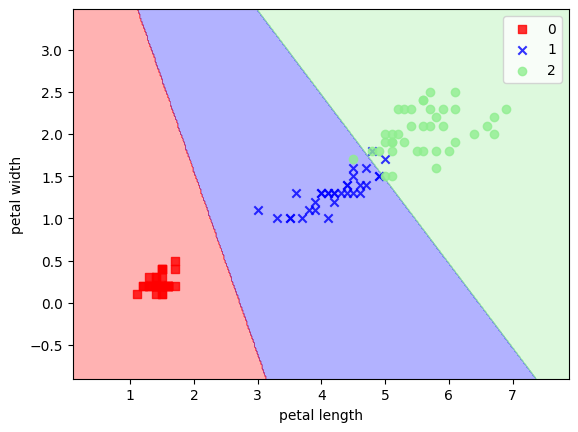

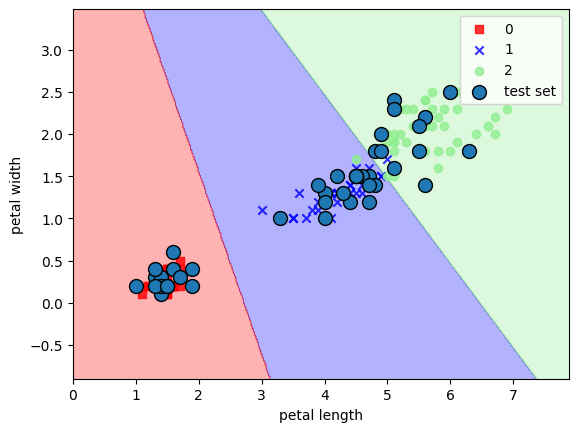

In [7]:

import matplotlib.pyplot as plt
from ml_lib.fig_func import plot_decision_regions

plot_decision_regions(
    X=X_train,
    y=y_train,
    classifier=model
)
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.legend()
plt.show()

plot_decision_regions(
    X=np.concatenate([X_train, X_test]),
    y=np.concatenate([y_train, y_test]),
    classifier=model, test_idx=range(105, 150)  # last 30% was set to test data
)
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.legend()
plt.show()

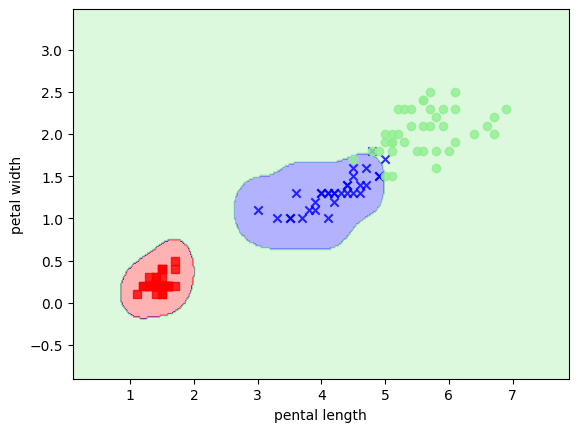

In [12]:

# Non-Linear SVM
# model2 = SVC(kernel='rbf', C=1.0, gamma=0.2, random_state=123)     ## good?
model2 = SVC(kernel='rbf', C=1.0, gamma=10, random_state=123)       ## over-fit
# model2 = SVC(kernel='rbf', C=1.0, gamma=0.01, random_state=123)     ## under-fit
"""
C:     Regularization parameter (inverse of regularization strength).
       This parameter controls the trade-off between maximizing the margin and minimizing classification errors.
           - Smaller C : stronger regularization (simpler model, wider margin).
           - Larger C : weaker regularization (fit training data more closely).

gamma: Kernel coefficient for RBF kernel.
       This parameter controls the influence range of each training sample.
           - Smaller gamma : broader influence (smoother decision boundary).
           - Larger gamma : narrower influence (more complex, localized decision boundary).
"""

model2.fit(X_train, y_train)

plot_decision_regions(
    X=X_train,
    y=y_train,
    classifier=model2
)
plt.xlabel('pental length')
plt.ylabel('petal width')
# plt.legend()
plt.show()
